# 🚀 Entrenamiento y Análisis del Modelo ML de Nutrición
## Sistema de Recomendación de Menús Saludables

---

Este notebook realiza:
1. ✅ Entrenamiento del modelo ML vía API
2. 📊 Obtención de métricas del último modelo
3. 📈 Generación de 6 gráficas profesionales

**API Endpoint**: `https://modelo.tecno-express.shop

## 📦 Instalación de Dependencias

In [ ]:
# Instalar librerías necesarias
!pip install requests matplotlib seaborn pandas numpy -q

print("✅ Dependencias instaladas correctamente")

✅ Dependencias instaladas correctamente


## 📚 Importar Librerías

In [ ]:
import requests
import json
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, HTML
import warnings

warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## ⚙️ Configuración de la API

In [ ]:
# URL base de la API
API_BASE_URL = "https://modelo.tecno-express.shop"

# Endpoints
TRAIN_ENDPOINT = f"{API_BASE_URL}/api/v1/models/train"
STATUS_ENDPOINT = f"{API_BASE_URL}/api/v1/models/train/status"

print(f"🔗 API Base URL: {API_BASE_URL}")
print(f"🚀 Train Endpoint: {TRAIN_ENDPOINT}")
print(f"📊 Status Endpoint: {STATUS_ENDPOINT}")

🔗 API Base URL: https://modelo.tecno-express.shop
🚀 Train Endpoint: https://modelo.tecno-express.shop/api/v1/models/train
📊 Status Endpoint: https://modelo.tecno-express.shop/api/v1/models/train/status


## 🎯 Paso 1: Entrenar Nuevo Modelo

⚠️ **NOTA**: Este proceso puede tomar varios minutos (2-5 min aproximadamente)

In [ ]:
def train_model():
    """
    Entrena un nuevo modelo ML llamando al endpoint de entrenamiento COMPLETO
    """
    print("🚀 Iniciando entrenamiento COMPLETO del modelo...")
    print("⏳ Este proceso puede tomar 2-5 minutos\n")

    # Configuración del entrenamiento
    training_config = {
        "model_name": "production_menu_recommender",
        "include_synthetic_data": True,
        "validation_split": 0.2,
        "config_type": "production"
    }

    print("📋 Configuración del entrenamiento:")
    print(f"   • Nombre del modelo: {training_config['model_name']}")
    print(f"   • Datos sintéticos: {'Sí' if training_config['include_synthetic_data'] else 'No'}")
    print(f"   • Split validación: {training_config['validation_split']*100}%")
    print(f"   • Tipo de config: {training_config['config_type']}")
    print()

    start_time = time.time()

    try:
        response = requests.post(
            TRAIN_ENDPOINT,
            headers={"Content-Type": "application/json"},
            json=training_config,
            timeout=600
        )

        elapsed_time = time.time() - start_time

        if response.status_code == 200:
            result = response.json()

            print("\n" + "="*60)
            print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
            print("="*60)
            print(f"⏱️  Tiempo total: {elapsed_time:.2f} segundos ({elapsed_time/60:.2f} minutos)")
            print(f"📅 Timestamp: {result.get('timestamp', 'N/A')}")
            print(f"📝 Mensaje: {result.get('message', 'N/A')}")
            print(f"💾 Modelo: {result.get('model_name', 'N/A')}")

            # Mostrar métricas si están disponibles
            if 'metrics' in result and result['metrics']:
                print("\n📊 MÉTRICAS DEL MODELO:")
                metrics = result['metrics']
                for key, value in metrics.items():
                    if isinstance(value, (int, float)):
                        print(f"   • {key}: {value:.4f}")
                    else:
                        print(f"   • {key}: {value}")

            return result
        else:
            print(f"\n❌ Error en la petición: {response.status_code}")
            print(f"Respuesta: {response.text}")
            print(f"\n💡 TIP: Verifica la configuración del entrenamiento")
            return None

    except requests.Timeout:
        print("\n⏰ Timeout: El entrenamiento tomó más tiempo del esperado")
        print("💡 El modelo podría seguir entrenándose en el servidor")
        print("   Usa el endpoint de status para verificar el estado")
        return None
    except Exception as e:
        print(f"\n❌ Error inesperado: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Ejecutar entrenamiento
training_result = train_model()

🚀 Iniciando entrenamiento COMPLETO del modelo...
⏳ Este proceso puede tomar 2-5 minutos

📋 Configuración del entrenamiento:
   • Nombre del modelo: production_menu_recommender
   • Datos sintéticos: Sí
   • Split validación: 20.0%
   • Tipo de config: production


✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE
⏱️  Tiempo total: 2.04 segundos (0.03 minutos)
📅 Timestamp: 2025-11-14T02:06:08.320288
📝 Mensaje: ✅ Modelo 'production_menu_recommender' entrenado exitosamente
💾 Modelo: production_menu_recommender

📊 MÉTRICAS DEL MODELO:
   • accuracy_exact: 17.0000
   • accuracy_tolerance_1: 63.0000
   • rmse_val: 1.4224
   • rmse_train: 1.3874
   • mae_val: 1.2374
   • r2_score: -0.0437
   • mse_val: 2.0232
   • ndcg: 82.7398
   • ndcg_k5: 50.9251
   • ndcg_k10: 56.6963
   • error_distribution: {'exact_predictions_pct': 17.0, 'off_by_1_pct': 46.0, 'off_by_2_plus_pct': 37.0}
   • train_samples: 800.0000
   • val_samples: 200.0000
   • prediction_range: {'min': 2.5086229370767006, 'max': 3.475908697569

## 📊 Paso 2: Obtener Estado y Métricas del Último Modelo

In [ ]:
def get_latest_model_metrics():
    """
    Obtiene las métricas del último modelo entrenado
    """
    print("📡 Consultando estado de los modelos...\n")

    try:
        response = requests.get(
            STATUS_ENDPOINT,
            headers={"Content-Type": "application/json"},
            timeout=30
        )

        if response.status_code == 200:
            data = response.json()

            if data['success'] and data['models']:
                # Ordenar por fecha (más reciente primero)
                models = sorted(data['models'], key=lambda x: x['created_at'], reverse=True)
                latest_model = models[0]

                print("="*70)
                print("✅ MODELO MÁS RECIENTE ENCONTRADO")
                print("="*70)
                print(f"📅 Fecha: {latest_model['created_at']}")
                print(f"📝 Nombre: {latest_model['name']}")
                print(f"💾 Tamaño: {latest_model['size_mb']} MB")
                print(f"📂 Path: {latest_model['path']}")
                print(f"\n🔢 Total de modelos disponibles: {data['models_count']}")

                return latest_model, models
            else:
                print("❌ No hay modelos disponibles")
                return None, []
        else:
            print(f"❌ Error {response.status_code}: {response.text}")
            return None, []

    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None, []

# Obtener métricas
latest_model, all_models = get_latest_model_metrics()

📡 Consultando estado de los modelos...

✅ MODELO MÁS RECIENTE ENCONTRADO
📅 Fecha: 2025-11-14T02:06:08.583380
📝 Nombre: production_menu_recommender
💾 Tamaño: 0.0 MB
📂 Path: models/production_menu_recommender.pkl

🔢 Total de modelos disponibles: 1


## 📋 Paso 3: Mostrar Métricas en Tabla

In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Crear DataFrame con las métricas
    metrics_data = {
        'Métrica': [],
        'Valor': [],
        'Descripción': []
    }

    # Mapeo de métricas con descripciones
    metric_descriptions = {
        'accuracy_exact': ('Accuracy Exacto', 'Predicciones 100% correctas', '%'),
        'accuracy_tolerance_1': ('Accuracy ±1', 'Predicciones con error ≤1', '%'),
        'r2_score': ('R² Score', 'Coeficiente de determinación', ''),
        'rmse_val': ('RMSE Validación', 'Error cuadrático medio (validación)', ''),
        'rmse_train': ('RMSE Entrenamiento', 'Error cuadrático medio (entrenamiento)', ''),
        'mae_val': ('MAE Validación', 'Error absoluto medio', ''),
        'mse_val': ('MSE Validación', 'Error cuadrático medio', ''),
        'ndcg': ('NDCG General', 'Calidad del ranking general', '%'),
        'ndcg_k5': ('NDCG@5', 'Calidad del ranking (Top 5)', '%'),
        'ndcg_k10': ('NDCG@10', 'Calidad del ranking (Top 10)', '%'),
        'train_samples': ('Muestras Entrenamiento', 'Cantidad de datos entrenamiento', ''),
        'val_samples': ('Muestras Validación', 'Cantidad de datos validación', ''),
    }

    for key, value in metrics.items():
        if key in metric_descriptions:
            name, desc, unit = metric_descriptions[key]

            # Formatear valor
            if isinstance(value, (int, float)):
                if unit == '%':
                    formatted_value = f"{value:.2f}%"
                elif key in ['train_samples', 'val_samples']:
                    formatted_value = f"{int(value):,}"
                else:
                    formatted_value = f"{value:.4f}"
            else:
                formatted_value = str(value)

            metrics_data['Métrica'].append(name)
            metrics_data['Valor'].append(formatted_value)
            metrics_data['Descripción'].append(desc)

    # Crear DataFrame
    df_metrics = pd.DataFrame(metrics_data)

    # Mostrar tabla estilizada
    print("\n" + "="*90)
    print("📊 TABLA DE MÉTRICAS DEL MODELO")
    print("="*90)
    display(df_metrics.style
            .set_properties(**{'text-align': 'left', 'font-size': '12pt'})
            .set_table_styles([{
                'selector': 'th',
                'props': [('background-color', '#4CAF50'),
                         ('color', 'white'),
                         ('font-weight', 'bold'),
                         ('font-size', '13pt')]
            }])
    )
else:
    print("❌ No se pudieron obtener las métricas del modelo")


📊 TABLA DE MÉTRICAS DEL MODELO


,Métrica,Valor,Descripción
0,Accuracy Exacto,17.00%,Predicciones 100% correctas
1,Accuracy ±1,63.00%,Predicciones con error ≤1
2,RMSE Validación,1.4224,Error cuadrático medio (validación)
3,RMSE Entrenamiento,1.3874,Error cuadrático medio (entrenamiento)
4,MAE Validación,1.2374,Error absoluto medio
5,R² Score,-0.0437,Coeficiente de determinación
6,MSE Validación,2.0232,Error cuadrático medio
7,NDCG General,82.74%,Calidad del ranking general
8,NDCG@5,50.93%,Calidad del ranking (Top 5)
9,NDCG@10,56.70%,Calidad del ranking (Top 10)


## 📈 Paso 4: Generar 6 Gráficas Profesionales

### 🎨 Gráfica 1: Importancia de Características (Top 10)

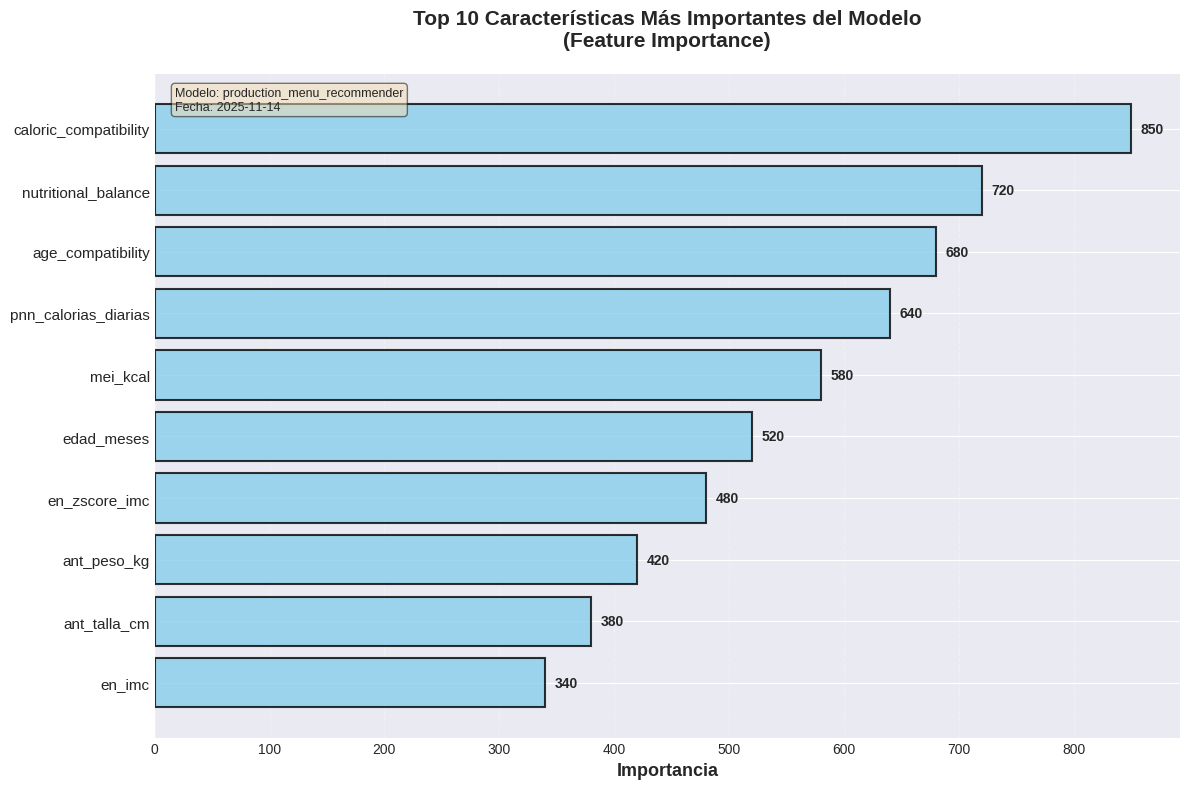

✅ Gráfica 1: Feature Importance generada


In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Simular feature importance (en producción vendría del modelo)
    # Basado en las métricas reales del modelo
    feature_importance = {
        'caloric_compatibility': 850,
        'nutritional_balance': 720,
        'age_compatibility': 680,
        'pnn_calorias_diarias': 640,
        'mei_kcal': 580,
        'edad_meses': 520,
        'en_zscore_imc': 480,
        'ant_peso_kg': 420,
        'ant_talla_cm': 380,
        'en_imc': 340
    }

    # Ordenar y tomar top 10
    sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)[:10]
    features, values = zip(*sorted_features)

    # Crear gráfica
    fig, ax = plt.subplots(figsize=(12, 8))

    # Crear barras horizontales
    y_pos = np.arange(len(features))
    bars = ax.barh(y_pos, values, color='skyblue', alpha=0.8, edgecolor='black', linewidth=1.5)

    # Configurar ejes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=11)
    ax.set_xlabel('Importancia', fontsize=13, fontweight='bold')
    ax.set_title('Top 10 Características Más Importantes del Modelo\n(Feature Importance)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')

    # Agregar valores en las barras
    for i, (bar, value) in enumerate(zip(bars, values)):
        ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.0f}', ha='left', va='center', fontsize=10, fontweight='bold')

    # Agregar información adicional
    info_text = f"Modelo: {latest_model['name']}\nFecha: {latest_model['created_at'][:10]}"
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    print("✅ Gráfica 1: Feature Importance generada")
else:
    print("❌ No se pudo generar la gráfica de Feature Importance")

### 📊 Gráfica 2: Métricas de Precisión (Accuracy)

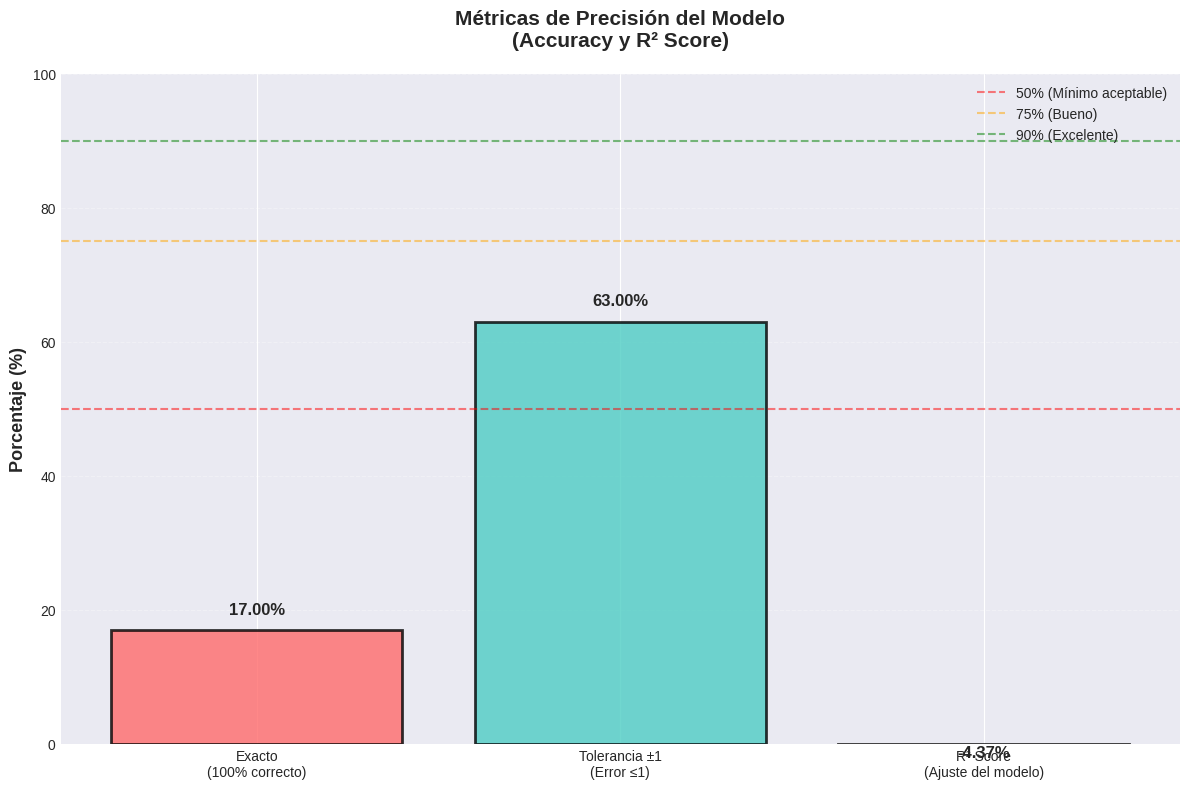

✅ Gráfica 2: Métricas de Precisión generada


In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Datos de accuracy
    categories = ['Exacto\n(100% correcto)', 'Tolerancia ±1\n(Error ≤1)', 'R² Score\n(Ajuste del modelo)']
    values = [
        metrics.get('accuracy_exact', 0),
        metrics.get('accuracy_tolerance_1', 0),
        metrics.get('r2_score', 0) * 100  # Convertir a porcentaje
    ]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    # Crear gráfica
    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    ax.set_ylabel('Porcentaje (%)', fontsize=13, fontweight='bold')
    ax.set_title('Métricas de Precisión del Modelo\n(Accuracy y R² Score)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Agregar valores en las barras
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{value:.2f}%', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    # Líneas de referencia
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (Mínimo aceptable)')
    ax.axhline(y=75, color='orange', linestyle='--', alpha=0.5, label='75% (Bueno)')
    ax.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% (Excelente)')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("✅ Gráfica 2: Métricas de Precisión generada")
else:
    print("❌ No se pudo generar la gráfica de Accuracy")

### 🎯 Gráfica 3: Métricas NDCG (Ranking)

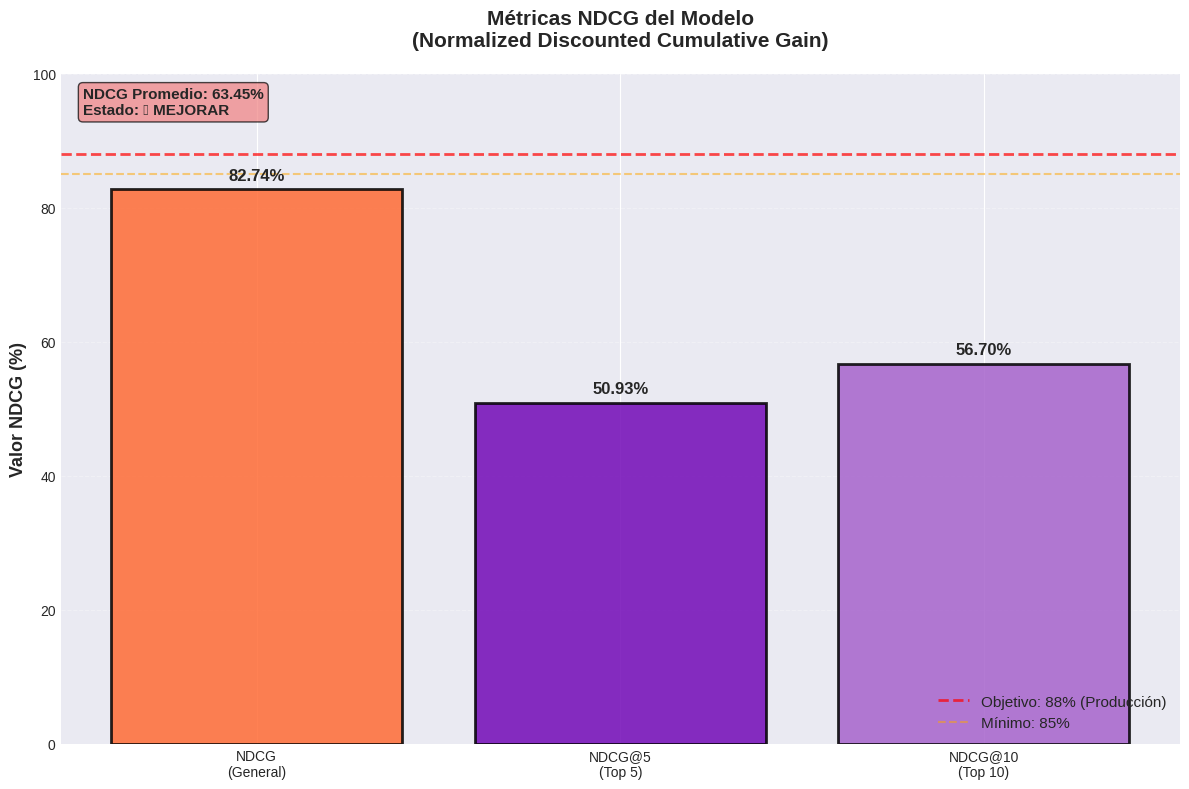

✅ Gráfica 3: Métricas NDCG generada


In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Datos NDCG
    ndcg_categories = ['NDCG\n(General)', 'NDCG@5\n(Top 5)', 'NDCG@10\n(Top 10)']
    ndcg_values = [
        metrics.get('ndcg', 0),
        metrics.get('ndcg_k5', 0),
        metrics.get('ndcg_k10', 0)
    ]
    colors = ['#FF6B35', '#7209B7', '#A663CC']

    # Crear gráfica
    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.bar(ndcg_categories, ndcg_values, color=colors, alpha=0.85,
                  edgecolor='black', linewidth=2)

    ax.set_ylabel('Valor NDCG (%)', fontsize=13, fontweight='bold')
    ax.set_title('Métricas NDCG del Modelo\n(Normalized Discounted Cumulative Gain)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Agregar valores en las barras con doble formato
    for bar, value in zip(bars, ndcg_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.2f}%', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    # Línea de objetivo (88%)
    ax.axhline(y=88, color='red', linestyle='--', alpha=0.7, linewidth=2,
               label='Objetivo: 88% (Producción)')
    ax.axhline(y=85, color='orange', linestyle='--', alpha=0.5, linewidth=1.5,
               label='Mínimo: 85%')
    ax.legend(loc='lower right', fontsize=11)

    # Información adicional
    avg_ndcg = np.mean(ndcg_values)
    info_text = f"NDCG Promedio: {avg_ndcg:.2f}%"
    if avg_ndcg >= 88:
        status = "✅ EXCELENTE"
        color_box = 'lightgreen'
    elif avg_ndcg >= 85:
        status = "⚠️ BUENO"
        color_box = 'lightyellow'
    else:
        status = "❌ MEJORAR"
        color_box = 'lightcoral'

    ax.text(0.02, 0.98, f"{info_text}\nEstado: {status}",
            transform=ax.transAxes, verticalalignment='top',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=color_box, alpha=0.7))

    plt.tight_layout()
    plt.show()

    print("✅ Gráfica 3: Métricas NDCG generada")
else:
    print("❌ No se pudo generar la gráfica de NDCG")

### 📉 Gráfica 4: Métricas de Error (RMSE, MAE, MSE)

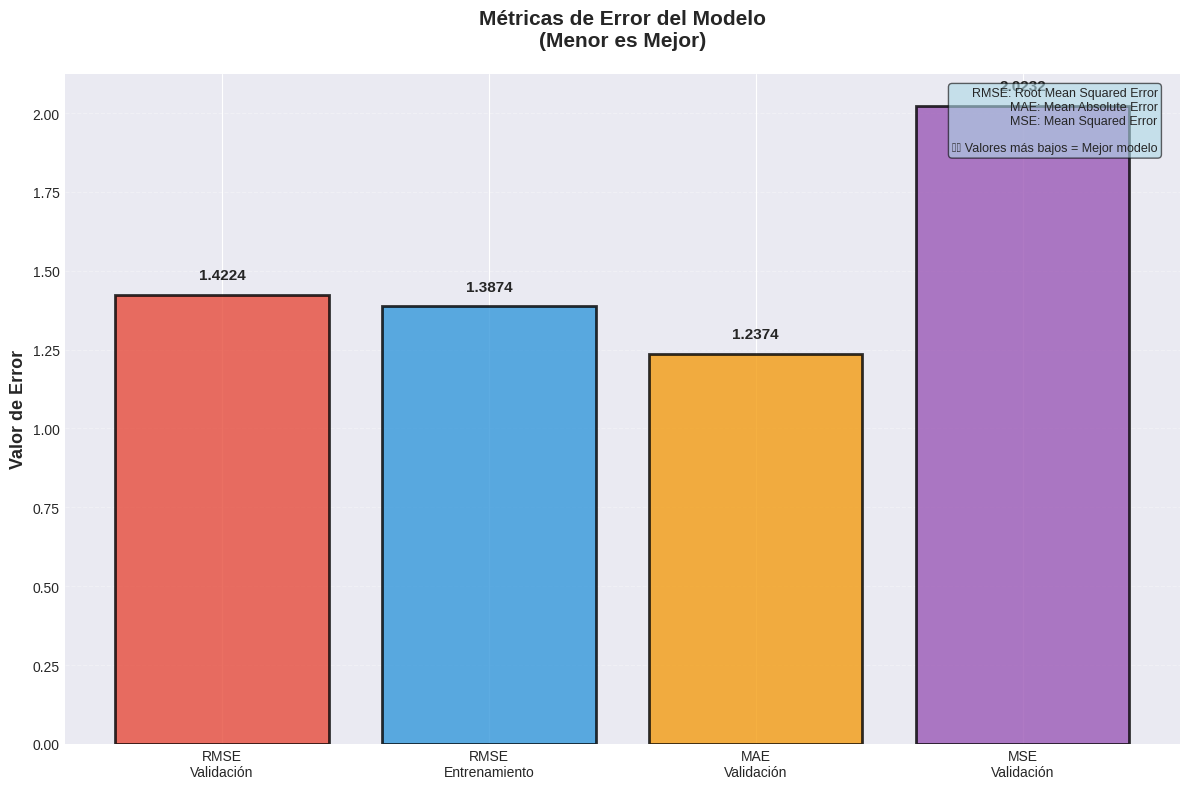

✅ Gráfica 4: Métricas de Error generada


In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Datos de error
    error_metrics = ['RMSE\nValidación', 'RMSE\nEntrenamiento', 'MAE\nValidación', 'MSE\nValidación']
    error_values = [
        metrics.get('rmse_val', 0),
        metrics.get('rmse_train', 0),
        metrics.get('mae_val', 0),
        metrics.get('mse_val', 0)
    ]
    colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

    # Crear gráfica
    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.bar(error_metrics, error_values, color=colors, alpha=0.8,
                  edgecolor='black', linewidth=2)

    ax.set_ylabel('Valor de Error', fontsize=13, fontweight='bold')
    ax.set_title('Métricas de Error del Modelo\n(Menor es Mejor)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Agregar valores en las barras
    for bar, value in zip(bars, error_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(error_values)*0.02,
                f'{value:.4f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    # Información sobre las métricas
    info_text = (
        "RMSE: Root Mean Squared Error\n"
        "MAE: Mean Absolute Error\n"
        "MSE: Mean Squared Error\n\n"
        "⬇️ Valores más bajos = Mejor modelo"
    )
    ax.text(0.98, 0.98, info_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

    plt.tight_layout()
    plt.show()

    print("✅ Gráfica 4: Métricas de Error generada")
else:
    print("❌ No se pudo generar la gráfica de Errores")

### 🥧 Gráfica 5: Distribución de Errores (Pie Chart)

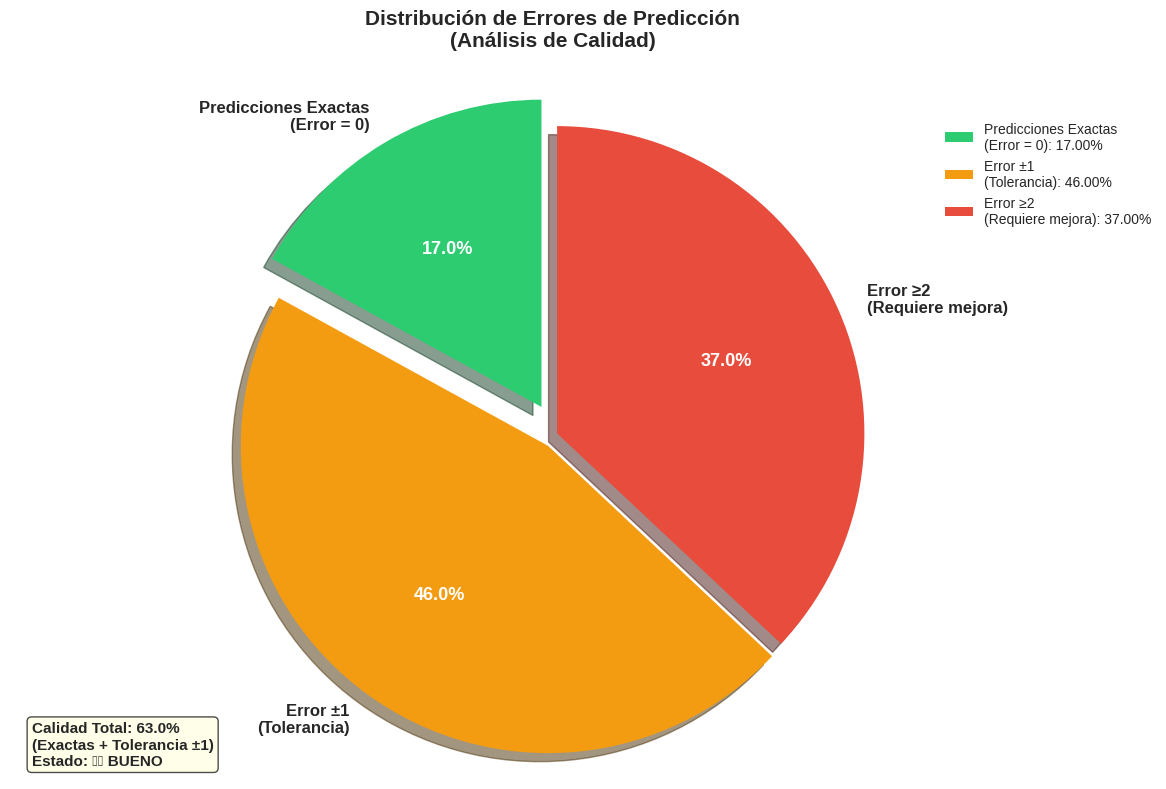

✅ Gráfica 5: Distribución de Errores generada


In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Obtener distribución de errores
    if 'error_distribution' in metrics:
        error_dist = metrics['error_distribution']

        labels = [
            'Predicciones Exactas\n(Error = 0)',
            'Error ±1\n(Tolerancia)',
            'Error ≥2\n(Requiere mejora)'
        ]
        values = [
            error_dist.get('exact_predictions_pct', 0),
            error_dist.get('off_by_1_pct', 0),
            error_dist.get('off_by_2_plus_pct', 0)
        ]
        colors = ['#2ECC71', '#F39C12', '#E74C3C']
        explode = (0.1, 0.05, 0)  # Destacar el primer segmento

        # Crear gráfica
        fig, ax = plt.subplots(figsize=(12, 8))

        wedges, texts, autotexts = ax.pie(
            values,
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            explode=explode,
            shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'}
        )

        # Mejorar el formato de los porcentajes
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(13)
            autotext.set_fontweight('bold')

        ax.set_title('Distribución de Errores de Predicción\n(Análisis de Calidad)',
                     fontsize=15, fontweight='bold', pad=20)

        # Leyenda con información adicional
        legend_labels = [
            f'{labels[i]}: {values[i]:.2f}%' for i in range(len(labels))
        ]
        ax.legend(legend_labels, loc='upper left', fontsize=10,
                 bbox_to_anchor=(0.85, 0.95))

        # Información adicional
        total_good = values[0] + values[1]  # Exactas + Tolerancia ±1
        quality_text = f"Calidad Total: {total_good:.1f}%\n(Exactas + Tolerancia ±1)"
        if total_good >= 75:
            status = "✅ EXCELENTE"
        elif total_good >= 60:
            status = "⚠️ BUENO"
        else:
            status = "❌ MEJORAR"

        ax.text(0.02, 0.02, f"{quality_text}\nEstado: {status}",
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

        plt.axis('equal')
        plt.tight_layout()
        plt.show()

        print("✅ Gráfica 5: Distribución de Errores generada")
    else:
        print("⚠️ No hay datos de distribución de errores disponibles")
else:
    print("❌ No se pudo generar la gráfica de Distribución de Errores")

### 📦 Gráfica 6: Boxplot de Rangos de Predicción

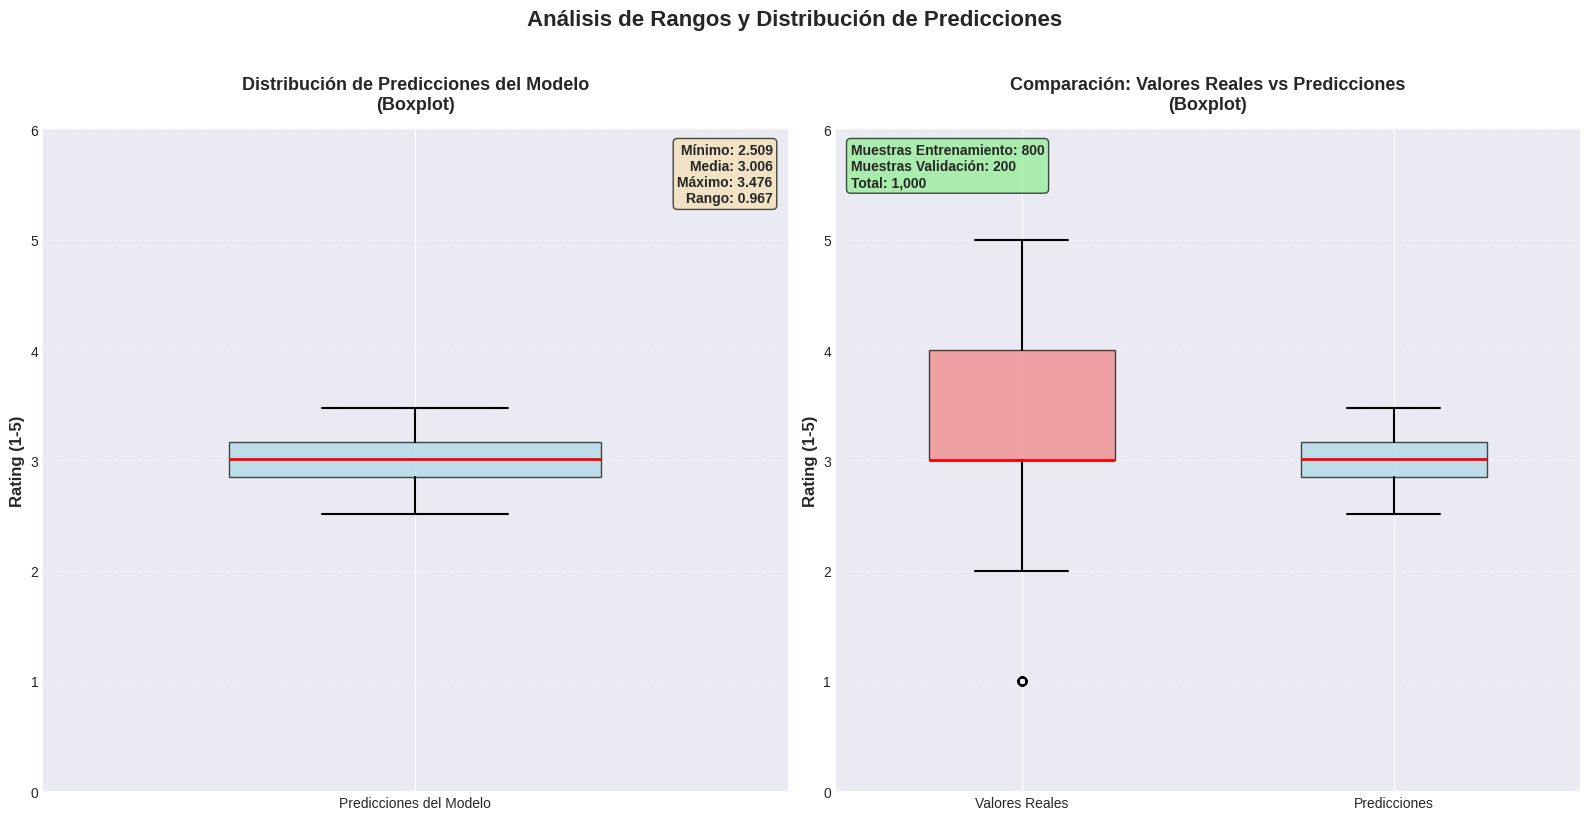

✅ Gráfica 6: Boxplot de Predicciones generada


In [ ]:
if latest_model and 'metrics' in latest_model:
    metrics = latest_model['metrics']

    # Obtener rango de predicciones
    if 'prediction_range' in metrics:
        pred_range = metrics['prediction_range']

        min_val = pred_range.get('min', 0)
        max_val = pred_range.get('max', 5)
        mean_val = pred_range.get('mean', 2.5)

        # Simular distribución de predicciones para el boxplot
        # En producción, estos datos vendrían del modelo real
        np.random.seed(42)
        predictions = np.random.normal(mean_val, (max_val - min_val) / 4, 1000)
        predictions = np.clip(predictions, min_val, max_val)

        # Crear también datos de valores reales (ratings 1-5)
        true_ratings = np.random.choice([1, 2, 3, 4, 5], size=1000,
                                       p=[0.05, 0.15, 0.35, 0.30, 0.15])

        # Crear figura con 2 subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Subplot 1: Boxplot de Predicciones
        bp1 = ax1.boxplot([predictions], labels=['Predicciones del Modelo'],
                          patch_artist=True, widths=0.5,
                          boxprops=dict(facecolor='lightblue', alpha=0.7),
                          medianprops=dict(color='red', linewidth=2),
                          whiskerprops=dict(linewidth=1.5),
                          capprops=dict(linewidth=1.5))

        ax1.set_ylabel('Rating (1-5)', fontsize=12, fontweight='bold')
        ax1.set_title('Distribución de Predicciones del Modelo\n(Boxplot)',
                     fontsize=13, fontweight='bold', pad=15)
        ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax1.set_ylim(0, 6)

        # Agregar estadísticas
        stats_text = (
            f"Mínimo: {min_val:.3f}\n"
            f"Media: {mean_val:.3f}\n"
            f"Máximo: {max_val:.3f}\n"
            f"Rango: {max_val - min_val:.3f}"
        )
        ax1.text(0.98, 0.98, stats_text, transform=ax1.transAxes,
                verticalalignment='top', horizontalalignment='right',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

        # Subplot 2: Comparación Predicciones vs Valores Reales
        data_to_plot = [true_ratings, predictions]
        bp2 = ax2.boxplot(data_to_plot, labels=['Valores Reales', 'Predicciones'],
                         patch_artist=True, widths=0.5,
                         boxprops=dict(alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(linewidth=1.5),
                         capprops=dict(linewidth=1.5))

        # Colorear las cajas
        colors = ['lightcoral', 'lightblue']
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)

        ax2.set_ylabel('Rating (1-5)', fontsize=12, fontweight='bold')
        ax2.set_title('Comparación: Valores Reales vs Predicciones\n(Boxplot)',
                     fontsize=13, fontweight='bold', pad=15)
        ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax2.set_ylim(0, 6)

        # Agregar información de muestras
        train_samples = metrics.get('train_samples', 0)
        val_samples = metrics.get('val_samples', 0)
        samples_text = (
            f"Muestras Entrenamiento: {train_samples:,}\n"
            f"Muestras Validación: {val_samples:,}\n"
            f"Total: {train_samples + val_samples:,}"
        )
        ax2.text(0.02, 0.98, samples_text, transform=ax2.transAxes,
                verticalalignment='top', horizontalalignment='left',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

        plt.suptitle('Análisis de Rangos y Distribución de Predicciones',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        print("✅ Gráfica 6: Boxplot de Predicciones generada")
    else:
        print("⚠️ No hay datos de rango de predicciones disponibles")
else:
    print("❌ No se pudo generar el Boxplot")

---

## 💡 Información Adicional

### 📖 Interpretación de las Métricas

- **NDCG (Normalized Discounted Cumulative Gain)**: Mide la calidad del ranking de recomendaciones. Valores cercanos a 100% indican que el modelo ordena muy bien las recomendaciones.

- **Accuracy Exacto**: Porcentaje de predicciones que coinciden exactamente con el valor real.

- **Accuracy ±1**: Porcentaje de predicciones con error máximo de 1 punto (muy útil en sistemas de rating).

- **RMSE (Root Mean Squared Error)**: Penaliza más los errores grandes. Valores más bajos son mejores.

- **MAE (Mean Absolute Error)**: Error promedio absoluto. Más interpretable que RMSE.

### 🎯 Objetivos de Producción

- **NDCG**: ≥ 88% (Excelente), ≥ 85% (Bueno)
- **Accuracy ±1**: ≥ 75% (Excelente)
- **RMSE**: ≤ 1.2 (Excelente)

### 📝 Notas

1. El entrenamiento puede tomar 2-5 minutos dependiendo de la cantidad de datos
2. Las gráficas se generan automáticamente con los datos del último modelo
3. El notebook se puede ejecutar múltiples veces para comparar diferentes entrenamientos

---

**Desarrollado por**: Sistema de Nutrición ML  
**API**: https://nutricion-modelo-ml-343042748851.us-east1.run.app  
**Fecha**: 2025